In [92]:
import pandas as pd
import matplotlib.pyplot as plt

## Is search interest for Ariana Grande's upcoming tour related to an increase in her Spotify  monthly streamers number?

![Ariana Grande's Eternal Sunshine tour poster](img/enternalsunshinetour.png)

### Introduction

As Ariana Grande continues to be one of the main faces in recent pop culture, she has maintained a cult following across multiple platforms. Specifically, with the massive success of Wicked and growing anticipation for her upcoming album Petal, fans have also been battling to try to secure ticket to her summer tour. Since artists can be found on various streaming platforms, their presence on social media and search engines can give us insight into how their popularity is measured. This analysis explores how public interest in Ariana Grande’s tour activity on Google Trends data compares to her Spotify monthly listener activity over time.

In [88]:
trends = pd.read_csv("ariana_trends.csv")
trends

,Time,"""Ariana Grande tour"""
0,2025-12-28,40
1,2026-01-04,76
2,2026-01-11,81
3,2026-01-18,50
4,2026-01-25,48
5,2026-02-01,37
6,2026-02-08,43
7,2026-02-15,44
8,2026-02-22,27
9,2026-03-01,35


Loading in the Google Trends data recorded so far is 2026 of search interest in "Ariana Grande tour". We can see in months where the tickets released, and now in the months leading up to her tour, the number of search interest has increased.

In [89]:
trends["Time"] = pd.to_datetime(trends["Time"])

In [90]:
trends["Month"] = trends["Time"].dt.month
monthly_interest = trends.groupby("Month")['"Ariana Grande tour"'].mean()

In [91]:
monthly_interest

Month
1      63.75
2      37.75
3      31.40
4      51.00
5     100.00
12     40.00
Name: "Ariana Grande tour", dtype: float64

By converting interest into the mean we can evalute search interest by months, giving us better intel into what periods of the year she has on average been more popular. Her album Petal was announced on April 28th, which may be reflecated by the increase in average tour searches from March (3) to April (4). 

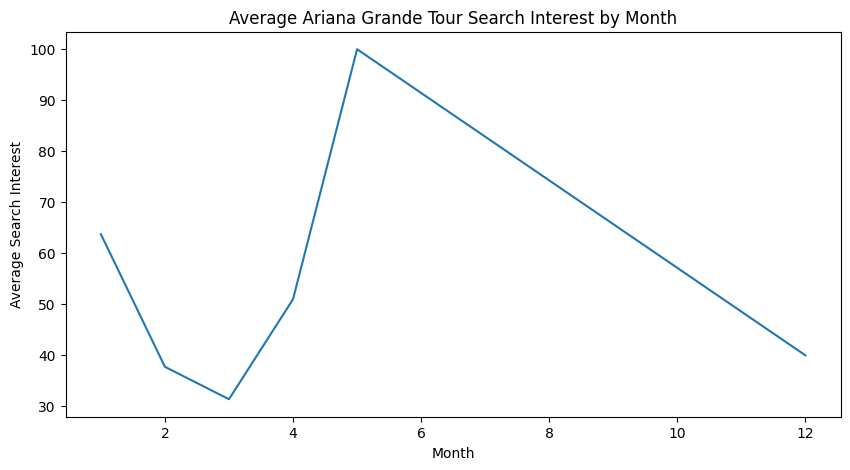

In [68]:
plt.figure(figsize=(10,5))

plt.plot(monthly_interest.index, monthly_interest.values)

plt.title("Average Ariana Grande Tour Search Interest by Month")
plt.xlabel("Month")
plt.ylabel("Average Search Interest")

plt.show()

This line plot visualizes that increases more clearly. Grande's tour interest started of slowing in the beginning of the year, possibily because tickets sold out by late 2025 and many fans were left defeated. 

https://www.yahoo.com/entertainment/music/articles/over-1-million-people-reportedly-233346753.html

However, she reannounced oppurtunities to acquire tickets through a ticketmaster lottery in late January going into Feburary which may explain the spike following march of potential fans trying to acquire tickets.

https://variety.com/2026/music/news/ticketmaster-to-re-sell-canceled-ariana-grande-tickets-1236643753/

In [69]:
spotify = pd.read_csv("spotify_data.csv")

spotify.head()

,date,followers,monthly_listeners,total_streams
0,2026-02-22,109810335,84967101,NaN
1,2026-02-23,109827867,84895934,NaN
2,2026-02-24,109841234,84815034,NaN
3,2026-02-25,109858447,84833818,NaN
4,2026-02-26,109858447,84774722,NaN


In [70]:
spotify["date"] = pd.to_datetime(spotify["date"])

In [71]:
spotify["Month"] = spotify["date"].dt.month

In [72]:
spotify_monthly = spotify.groupby("Month")["monthly_listeners"].mean()

spotify_monthly

Month
2    8.479385e+07
3    8.283391e+07
4    8.251130e+07
5    8.388795e+07
Name: monthly_listeners, dtype: float64

Converting the sportify data into means so it can be compared to to the Google Trends data. This Data contains Grande's monthly listeners count which is a metric the Spotify has available for all artists that upload content on their platform.

![Ariana Grande has the 3rd most listeners on Spotify](img/listenercount.png)

In [81]:
comparison = pd.DataFrame({
    "Google_Trends": monthly_interest,
    "Spotify_Listeners": spotify_monthly
})

comparison

,Google_Trends,Spotify_Listeners
Month,,
1,63.75,NaN
2,37.75,8.479385e+07
3,31.40,8.283391e+07
4,51.00,8.251130e+07
5,100.00,8.388795e+07
12,40.00,NaN


This table compares Grande's average amount of monthly listeners to her average Goodgle trends search for "Ariana Grande Tour"

#### Comparing Across Time

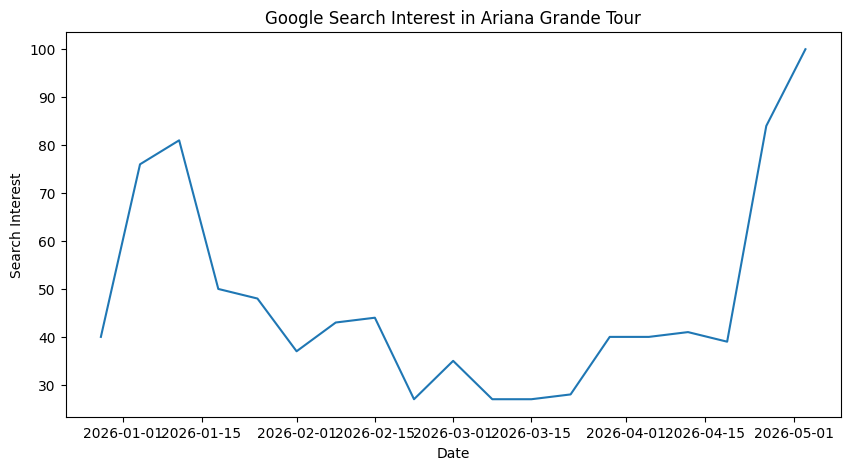

In [82]:
plt.figure(figsize=(10,5))

plt.plot(trends["Time"], trends['"Ariana Grande tour"'])

plt.title("Google Search Interest in Ariana Grande Tour")
plt.xlabel("Date")
plt.ylabel("Search Interest")

plt.show()

The Google Trends plot showcases how public search interest in Ariana Grande’s tour fluctuated over time. Search interest peaked in early January and again in early May, which suggests that there may have been moments of increased public attention or mentions in media regarding Ariana Grande and her album teasers.

Following those peaks, "Ariana Grande tour" search interest declined and stayed around those lower levels which tell us that the number of people who seek out tour-related topics may rise around major cultural events before the buzz dies and eventually tapers off.

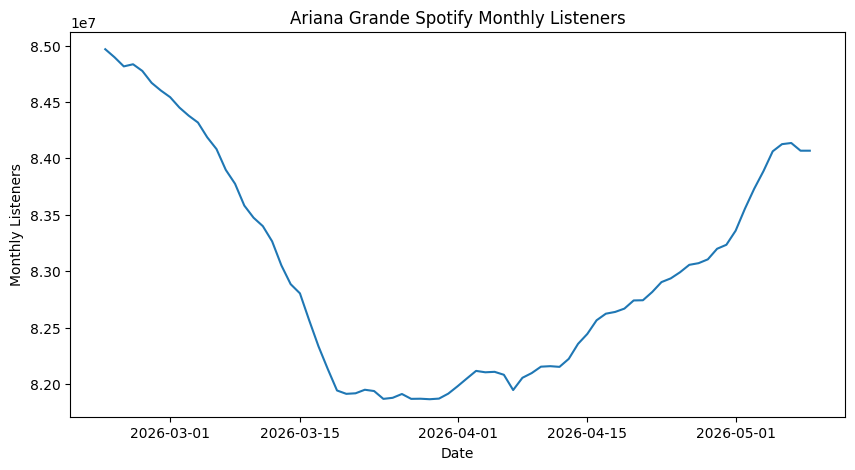

In [85]:
plt.figure(figsize=(10,5))

plt.plot(spotify["date"], spotify["monthly_listeners"])

plt.title("Ariana Grande Spotify Monthly Listeners")
plt.xlabel("Date")
plt.ylabel("Monthly Listeners")

plt.show()

On the other hand, Ariana Grande’s Spotify monthly listeners haveremained pretty stable over past months. Although there was a noticeable decline in listeners throughout March, listener counts  began to rise again throughout April and early May. 

Overall, Spotify listener data exhibits more consistent and long-term audience engagement, which tells us that streaming behavior is less dependent on short-term spikes in public attention.

In [86]:
comparison["Google_Trends"].corr(comparison["Spotify_Listeners"])

np.float64(0.1527973660559013)

To further examine wheter the two are actaully related, this correlation calculation, which compares Google Trends and Spontify monthly averages, shows that there is a weak positive relationship of 0.15. This result tell us that an increase in search interest for Ariana Grande's tour does not alawys carry over into an increase in her monthly streaming activity.

# Conclusion

Overall, this analysis reveals that Ariana Grande's online presence varies depending on how and where it's measured. Google Trends captured more sharp spikes in public attention that can be tied to major moments like music releases and media coverage whereas Spotify listener counts remained considerably steady over time. While the correlation between the two datasets was weak, together the data demonstrates that Ariana Grande has been able to sustain a strong digital presence and is keeping up the momentum into her next body of work.